# Evaluation Code for Article Extraction with LLMs

*Notebook created by Johanna Mauermann* [![ORCID](https://info.orcid.org/wp-content/uploads/2019/11/orcid_16x16.png)](https://orcid.org/0009-0000-4790-8196)

___

This notebook contains code to evaluate the performance of Large Language Models (LLMs) in an article extraction task by comparing their output to a manually curated ground truth. For each article identified by the LLM, the code determines a match status and calculates a success score. It categorizes outcomes into True Positives, False Positives, False Negatives, and True Negatives, while identifying specific issues such as Over-Extraction or Under-Extraction (when the LLM extracts too much or too little text), Content Mismatch (indicated by a high Levenshtein distance), and Formatting Errors (when article boundaries differ from the ground truth).

The notebook also features visualizations that illustrate key insights from our evaluation results.

## Main function for matching articles

This function tries to find matches between ground truth and LLM articles.

In [ ]:
# main function for alignment
import pandas as pd
!pip install fuzzywuzzy
!pip install Python-Levenshtein
from fuzzywuzzy import fuzz # to handle cases where there is no perfect match, but a fuzzy match
import Levenshtein  # for Levenshtein distance
import re

# Parameters - You can change these
N = 50  # Number of characters to use for start/end snippets
threshold = 65  # Similarity threshold for matching

def match_articles(row, llm_column, gt_column='article_ground_truth', N=50, threshold=65):
    """
    Aligns start and end boundaries between ground truth and LLM output using two-way fuzzy matching.
    Calculates levenshtein distance between found start/end matches.
    Handles edge cases, such as "No relevant article found" or none-values.
    Determines whether LLM omitted or added something, compared to the ground truth.

    """
    results = []

    gt_text = row[gt_column]
    llm_text = row[llm_column]

    # first, check for none/na values -> return list with alignment status "Incomplete Data" if there are any
    if pd.isna(gt_text) or pd.isna(llm_text):
        append_result(results, aligned = False, match_status = "Incomplete Data", start_matched_text = None, end_matched_text = None, distance_to_llm_start = None, distance_to_llm_end = None, lev_distance = None, normalized_lev_distance = None, normalized_omitted_characters = None, normalized_added_characters = None, human_verification_needed = False, success_score = None)
        return results

    ground_truth_list = transform_to_dict(gt_text) # call helper function, to format our data
    llm_list = transform_to_dict(llm_text)

    # deal with "No relevant article found" edge case
    pattern = r"(Kein relevanter Artikel|No relevant article|\[\]|Aucun article pertinent|<article>\s*</article>|<articles>\s*</articles>|<no_relevant_article_found>\s*True\s*</no_relevant_article_found>)"

    gt_matches = [gt_dict for gt_dict in ground_truth_list if re.match(pattern, gt_dict.get("article", ""))]
    llm_matches = [llm_dict for llm_dict in llm_list if re.match(pattern, llm_dict.get("article", ""))]

    # true negative, if both LLM and ground truth don't identify any relevant articles
    if gt_matches and llm_matches:
      append_result(results, aligned = False, match_status = "True Negative", start_matched_text = None, end_matched_text = None, distance_to_llm_start = 0, distance_to_llm_end = 0, lev_distance = 0, normalized_lev_distance = 0, normalized_omitted_characters = 0, normalized_added_characters = 0, human_verification_needed = llm_matches[0].get("human_verification_needed", False), success_score = 1)
      return results

    # False negative(s) if the ground truth identifies one or more articles, while the LLM doesn't
    if not gt_matches and llm_matches:
      for gt_dict in ground_truth_list:
        append_result(results, aligned = False, match_status = "False Negative", start_matched_text = None, end_matched_text = None, distance_to_llm_start = None, distance_to_llm_end = None, lev_distance = None, normalized_lev_distance = None, normalized_omitted_characters = None, normalized_added_characters = None, human_verification_needed = llm_matches[0].get("human_verification_needed", False), success_score = 0)
      return results

    # False positive(s) if the LLM identifies articles while there aren't any in the ground truth
    if gt_matches and not llm_matches:
      for llm_dict in llm_list:
        append_result(results, aligned = False, match_status = "False Positive", start_matched_text = None, end_matched_text = None, distance_to_llm_start = None, distance_to_llm_end = None, lev_distance = None, normalized_lev_distance = None, normalized_omitted_characters = None, normalized_added_characters = None, human_verification_needed = llm_dict.get("human_verification_needed", False), success_score = 0)
      return results

    # lists to track all articles that match
    all_matched_articles_gt = []
    all_matched_articles_llm = []

    if len(llm_list) <= len(ground_truth_list):

      for llm_dict in llm_list:

          matched_articles_gt = []

          llm_text = llm_dict.get("article", "")

          # For each ground truth entry, determine if it matches the LLM entry
          for gt_dict in ground_truth_list:
              gt_text = gt_dict.get("article", "")

              matching = article_matches(gt_text, llm_text)

              if matching:
                matched_articles_gt.append(gt_text)
                all_matched_articles_gt.append(gt_text)

          formatting_error = False

          if len(matched_articles_gt) == 0: # if no match is found, return false positive
            append_result(results, aligned = False, match_status = "False Positive", start_matched_text = None, end_matched_text = None, distance_to_llm_start = None, distance_to_llm_end = None, lev_distance = None, normalized_lev_distance = None, normalized_omitted_characters = None, normalized_added_characters = None, human_verification_needed = llm_dict.get("human_verification_needed", False), success_score = 0)
            return results

          # if more than one article matches, it's a formatting error
          if len(matched_articles_gt) > 1:
            formatting_error = True

          # in case multiple articles have been matched, we concatenate them for metrics calculation
          gt_text = " ".join(matched_articles_gt)

          gt_start_snippet = get_character_snippet(gt_text, 0, N)
          gt_end_snippet = get_character_snippet(gt_text, -N, N)

          # Initialize variables
          start_matched_text = None
          end_matched_text = None
          distance_to_llm_start = None
          distance_to_llm_end = None

          (
                start_position,
                start_score,
                start_matched_text,
                distance_to_llm_start,
                end_position,
                end_score,
                end_matched_text,
                distance_to_llm_end
            ) = calculate_start_end_distances(gt_text, llm_text, gt_start_snippet, gt_end_snippet, N, threshold)


          if distance_to_llm_start is not None and distance_to_llm_end is not None:
                lev_distance, normalized_lev_distance = calculate_levenshtein(gt_text, llm_text, distance_to_llm_start, distance_to_llm_end)
          else:
                lev_distance = None
                normalized_lev_distance = None

          # Normalize omitted and added characters based on start distance and end distance values
          normalized_omitted_characters, normalized_added_characters = normalize_extraction(distance_to_llm_start, distance_to_llm_end, gt_text, llm_text)

          # calculate success score and determine match status via helper functions
          success_score = calculate_success_score(normalized_lev_distance, normalized_omitted_characters, normalized_added_characters, formatting_error)
          match_status = determine_match_status(normalized_lev_distance, normalized_omitted_characters, normalized_added_characters, formatting_error)

          # Append results
          if start_score is not None and end_score is not None and lev_distance is not None:
              append_result(results, aligned = True, match_status = match_status, start_matched_text = start_matched_text, end_matched_text=end_matched_text, distance_to_llm_start = distance_to_llm_start, distance_to_llm_end = distance_to_llm_end, lev_distance = lev_distance, normalized_lev_distance = normalized_lev_distance, normalized_omitted_characters = normalized_omitted_characters, normalized_added_characters = normalized_added_characters, human_verification_needed = llm_dict.get("human_verification_needed", "Unclear"), success_score = success_score)
          else:
              append_result(results, aligned = False, match_status = "False Positive", start_matched_text = None, end_matched_text = None, distance_to_llm_start = None, distance_to_llm_end = None, lev_distance = None, normalized_lev_distance = None, normalized_omitted_characters = None, normalized_added_characters = None, human_verification_needed = llm_dict.get("human_verification_needed", "Unclear"), success_score = 0)

      for gt_dict in ground_truth_list:
        gt_text = gt_dict.get("article", "")
        if gt_text not in all_matched_articles_gt:
          append_result(results, aligned = False, match_status = "False Negative", start_matched_text = None, end_matched_text = None, distance_to_llm_start = None, distance_to_llm_end = None, lev_distance = None, normalized_lev_distance = None, normalized_omitted_characters = None, normalized_added_characters = None, human_verification_needed = llm_dict.get("human_verification_needed", "Unclear"), success_score = 0)

    # reverse direction if there are more articles identified by the LLM than in the ground truth
    if len(llm_list) > len(ground_truth_list):

      for gt_dict in ground_truth_list:

            matched_articles_llm = []

            gt_text = gt_dict.get("article", "")

            # For each llm entry, determine if it matches the ground truth entry
            for llm_dict in llm_list:
                llm_text = llm_dict.get("article", "")

                matching = article_matches(gt_text, llm_text)

                if matching:
                  matched_articles_llm.append(llm_text)
                  all_matched_articles_llm.append(llm_text)
            formatting_error = False

            if len(matched_articles_llm) == 0: # if no match is found, return false negative
              append_result(results, aligned = False, match_status = "False Negative", start_matched_text = None, end_matched_text = None, distance_to_llm_start = None, distance_to_llm_end = None, lev_distance = None, normalized_lev_distance = None, normalized_omitted_characters = None, normalized_added_characters = None, human_verification_needed = None, success_score = 0)
              return results

            if len(matched_articles_llm) > 1:
              formatting_error = True

            # concatenate all found articles
            llm_text = " ".join(matched_articles_llm)

            # Ground truth snippet
            gt_start_snippet = get_character_snippet(gt_text, 0, N)
            gt_end_snippet = get_character_snippet(gt_text, -N, N)

            # Initialize variables
            start_matched_text = None
            end_matched_text = None
            distance_to_llm_start = None
            distance_to_llm_end = None

            (
                start_position,
                start_score,
                start_matched_text,
                distance_to_llm_start,
                end_position,
                end_score,
                end_matched_text,
                distance_to_llm_end
            ) = calculate_start_end_distances(gt_text, llm_text, gt_start_snippet, gt_end_snippet, N, threshold)

            # Calculate Levenshtein distance between aligned sections
            if distance_to_llm_start is not None and distance_to_llm_end is not None:
                lev_distance, normalized_lev_distance = calculate_levenshtein(gt_text, llm_text, distance_to_llm_start, distance_to_llm_end)
            else:
                lev_distance = None
                normalized_lev_distance = None

            # Normalize omitted and added characters based on start distance and end distance values
            normalized_omitted_characters, normalized_added_characters = normalize_extraction(distance_to_llm_start, distance_to_llm_end, gt_text, llm_text)

            success_score = calculate_success_score(normalized_lev_distance, normalized_omitted_characters, normalized_added_characters, formatting_error)
            match_status = determine_match_status(normalized_lev_distance, normalized_omitted_characters, normalized_added_characters, formatting_error)

            if start_score is not None and end_score is not None and lev_distance is not None:
                append_result(results, aligned = True, match_status = match_status, start_matched_text = start_matched_text, end_matched_text = end_matched_text, distance_to_llm_start = distance_to_llm_start, distance_to_llm_end = distance_to_llm_end, lev_distance = lev_distance, normalized_lev_distance = normalized_lev_distance, normalized_omitted_characters = normalized_omitted_characters, normalized_added_characters = normalized_added_characters, human_verification_needed = None, success_score = success_score)
            else:
                append_result(results, aligned = False, match_status = "False Negative", start_matched_text = None, end_matched_text = None, distance_to_llm_start = None, distance_to_llm_end = None, lev_distance = None, normalized_lev_distance = None, normalized_omitted_characters = None, normalized_added_characters = None, human_verification_needed = None, success_score = 0)

      for llm_dict in llm_list:
            llm_text = llm_dict.get("article", "")
            if llm_text not in all_matched_articles_llm:
              append_result(results, aligned = False, match_status = "False Positive", start_matched_text = None, end_matched_text = None, distance_to_llm_start = None, distance_to_llm_end = None, lev_distance = None, normalized_lev_distance = None, normalized_omitted_characters = None, normalized_added_characters = None, human_verification_needed = llm_dict.get("human_verification_needed", "Unclear"), success_score = 0)

    return results

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.4 MB/s eta 0:00:00


## Helper functions to match snippets

In [ ]:
# helper function for fuzzy matching
def best_fuzzy_match_char(target_snippet, search_text, N, threshold):
    """
    Finds the best fuzzy match for a target snippet within the search text.
    Handles cases where search text is shorter than target snippet.
    """

    #target_snippet = target_snippet.lower()
    #search_text = search_text.lower()

    best_score = 0
    best_position = None

    # If search text is shorter than N characters, compare with entire search text
    if len(search_text) < N:
        score = fuzz.partial_ratio(target_snippet, search_text)
        if score >= threshold:
            return 0, score
        return None, 0

    # For longer texts, slide the window
    for i in range(len(search_text) - N + 1):
        window_text = search_text[i:i + N]
        score = fuzz.partial_ratio(target_snippet, window_text)

        if score > best_score and score >= threshold:
            best_score = score
            best_position = i

    # If we found no match above threshold, try one last time with the full text
    if best_position is None:
        full_score = fuzz.partial_ratio(target_snippet, search_text)
        if full_score >= threshold:
            return 0, full_score

    return best_position, best_score

# Helper function to make matching more robust
def get_character_snippet(text, position, N):
    """
    Extracts a snippet of N characters from a text starting at a given position.
    Handles cases where text is shorter than N characters.
    """
    if len(text) < N:
        return text  # Return entire text if shorter than N

    if position >= 0:
        return text[position:position + N]
    else:
        # For negative positions, ensure we get exactly N characters if possible
        start = max(len(text) + position, 0)  # Avoid negative start index
        return text[start:start + N]


## Helper function: transform_to_dict

*   This function converts text, either in a single string format or an XML format with article tags, into a standardized dictionary format. When using the tag format, the dictionary also includes the article's human_verification_needed information (if it exists). Additionally, this function is planned to support various output formats beyond just tags in the future.
*   The function "normalize_text" is called to remove unneccessary line breaks, white spaces and xml tags



In [ ]:
import re

def transform_to_dict(text):
    dict_list = []

    # Patterns for extracting articles and human verification
    article_pattern = r'<article>([\s\S]*?)</article>'

    # Handle articles with asterisks around tags
    special_article_pattern = r'\*\*<article>\*\*([\s\S]*?)\*\*</article>\*\*'

    verification_patterns = [
        r'<human_verification_needed>(.*?)</human_verification_needed>',
        r'\*\*<human_verification_needed>\*\*(.*?)\*\*</human_verification_needed>\*\*',
        r'\*\*Vérification humaine nécessaire\*\*\s*\*?(True|False)\*?',
        r'\*\*Human Verification\*\*\s*\*?(True|False)\*?',
        r'\*\*Human Verification:\*\*\s*\*?(True|False)\*?',
        r'\*human_verification_needed\*\s*>\s*\*(True|False)\*',
        r'verification.*?needed\s*:\s*(true|false)',
        r'human_verification_needed\s*:\s*(true|false)'
    ]

    irrelevant_pattern = r"(Kein relevanter Artikel|No relevant article|\[\]|Aucun article pertinent|<article>\s*</article>|<articles>\s*</articles>|<no_relevant_article_found>\s*True\s*</no_relevant_article_found>)"

    # Extract human verification with multiple pattern attempts
    human_verification = False  # Default

    for pattern in verification_patterns:
        verification_match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
        if verification_match:
            # Extract the verification value and remove any asterisks
            raw_value = verification_match.group(1).strip()
            verification_value = re.sub(r'\*', '', raw_value).lower()
            human_verification = verification_value == 'true'
            break

    # Extract all articles using both patterns
    article_matches = []
    # Standard article tags
    standard_matches = re.findall(article_pattern, text, re.IGNORECASE | re.DOTALL)
    if standard_matches:
        article_matches.extend(standard_matches)

    # Article tags with asterisks
    special_matches = re.findall(special_article_pattern, text, re.IGNORECASE | re.DOTALL)
    if special_matches:
        article_matches.extend(special_matches)

    # Handle special formatting with markdown
    markdown_article_tags = re.findall(r'\*\*\*Article.*?\*\*([\s\S]*?)(?:\*\*\*|$)', text, re.IGNORECASE | re.DOTALL)
    if markdown_article_tags:
        article_matches.extend(markdown_article_tags)

    irrelevant_matches = re.findall(irrelevant_pattern, text, re.DOTALL)

    # edge case handling for cases with mismatched open and closing tags
    open_tags = len(re.findall(r"<article>", text, re.IGNORECASE))
    close_tags = len(re.findall(r"</article>", text, re.IGNORECASE))

    # Check for "no relevant article" cases
    no_relevant_article = (
        (irrelevant_matches and not article_matches) or
        ("<article></article>" in text) or
        not article_matches
    )

    if no_relevant_article:
        dict_list.append({
            'article': 'No relevant article found.',
            'all_articles_on_page': normalize_text(text.strip()),
            'human_verification_needed': human_verification
        })
        return dict_list

    # Normalize and combine all articles into a single string
    combined_article = normalize_text(" ".join(article_matches).strip())

    # Create a list of dictionaries for each article
    for article_text in article_matches:
        # Normalize the article text
        normalized_article = normalize_text(article_text)

        dict_list.append({
            'article': normalized_article,
            'all_articles_on_page': combined_article,
            'human_verification_needed': human_verification
        })

    return dict_list

def normalize_text(text):


    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    text = ' '.join(text.split())
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)

    # Remove additional tags
    text = re.sub(r'<title>.*?</title>', '', text, flags=re.DOTALL)
    text = re.sub(r'<headline>.*?</headline>', '', text, flags=re.DOTALL)
    text = re.sub(r'</?(content|paragraph|contenu|section|inhalt)>.*?</\1>', '', text, flags=re.DOTALL)
    text = re.sub(r'<verification>.*?</verification>', '', text, flags=re.DOTALL)



    return text.strip()

## Helper function: article_matches

This helper function is called iteratively in the main function. For each article, it determines if there is a match by trying to align start and end snippets. If a match is found, it returns "True", otherwise "False".

In [ ]:
def article_matches(gt_text, llm_text):
    # Ground truth snippets
    gt_start_snippet = get_character_snippet(gt_text, 0, N)
    gt_end_snippet = get_character_snippet(gt_text, -N, N)

    # Forward search in LLM text
    start_position, start_score = best_fuzzy_match_char(gt_start_snippet, llm_text, N, threshold)
    end_position, end_score = best_fuzzy_match_char(gt_end_snippet, llm_text, N, threshold)

    rev_start_position, rev_start_score = None, None
    rev_end_position, rev_end_score = None, None

    # Handle start position and distance
    if start_position is None:
        # Reverse search from LLM to GT, if forward search fails
        rev_start_position, rev_start_score = best_fuzzy_match_char(
            get_character_snippet(llm_text, 0, N),
            gt_text,
            N,
            threshold
        )

    if end_position is None:
        # Reverse search from end, if forward search fails
        llm_end_snippet = get_character_snippet(llm_text, -N, N)
        rev_end_position, rev_end_score = best_fuzzy_match_char(llm_end_snippet, gt_text, N, threshold)

    # Evaluate results
    start_match = start_position is not None or rev_start_position is not None
    end_match = end_position is not None or rev_end_position is not None

    return start_match and end_match


## Helper function: calculate_start_end_distances

For matched articles, this function determines whether and by how many characters the start and end of the Ground Truth article differ from the LLM article. A negative value indicates omitted characters, while a positive value signifies added characters.


In [ ]:
def calculate_start_end_distances(gt_text, llm_text, gt_start_snippet, gt_end_snippet, N, threshold):
    start_matched_text, end_matched_text = None, None
    distance_to_llm_start, distance_to_llm_end = None, None

    # Forward search
    start_position, start_score = best_fuzzy_match_char(gt_start_snippet, llm_text, N, threshold)
    end_position, end_score = best_fuzzy_match_char(gt_end_snippet, llm_text, N, threshold)

    # Reverse search if not found
    if start_position is None:
        rev_start_position, rev_start_score = best_fuzzy_match_char(get_character_snippet(llm_text, 0, N), gt_text, N, threshold)
        if rev_start_position is not None:
            start_matched_text = gt_text[rev_start_position:rev_start_position + N]
            start_score = rev_start_score
            distance_to_llm_start = -rev_start_position
    else:
        start_matched_text = llm_text[start_position:start_position + N]
        distance_to_llm_start = start_position

    if end_position is None:
        llm_end_snippet = get_character_snippet(llm_text, -N, N)
        rev_end_position, rev_end_score = best_fuzzy_match_char(llm_end_snippet, gt_text, N, threshold)
        if rev_end_position is not None:
            end_matched_text = gt_text[rev_end_position:rev_end_position + N]
            end_score = rev_end_score
            distance_to_llm_end = -(len(gt_text) - (rev_end_position + N))
    else:
        end_matched_text = llm_text[end_position:end_position + N]
        llm_distance_from_end = len(llm_text) - (end_position + N)
        gt_distance_from_end = 0  # GT ends here, as it's the gold standard
        distance_to_llm_end = llm_distance_from_end - gt_distance_from_end

    return (
        start_position,
        start_score,
        start_matched_text,
        distance_to_llm_start,
        end_position,
        end_score,
        end_matched_text,
        distance_to_llm_end
    )


## Helper Function: append_result

Appends a dictionary, the values depending on the calculated metrics for the respective article.

In [ ]:
def append_result(results, aligned, match_status, start_matched_text, end_matched_text, distance_to_llm_start, distance_to_llm_end, lev_distance, normalized_lev_distance, normalized_omitted_characters, normalized_added_characters, human_verification_needed, success_score):
    results.append({
        'aligned': aligned,
        'match_status': match_status,
        'start_matched_text': start_matched_text,
        'end_matched_text': end_matched_text,
        'start_distance': distance_to_llm_start,
        'end_distance': distance_to_llm_end,
        'levenshtein_distance': lev_distance,
        'normalized_levenshtein': normalized_lev_distance,
        'normalized_omitted_characters': normalized_omitted_characters,
        'normalized_added_characters': normalized_added_characters,
        'human_verification_needed': human_verification_needed,
        'success_score': success_score
    })


## Helper function: calculate_success_score

Starting from the perfect score 1, this function calculates a score for all aligned articles by subtracting relative to the *normalized_lev_distance*, *normalized_omitted_characters*, and *normalized_added_characters* values (weighing omitted characters x1,5, as even a very small percentage of missing characters can be a significant issue).

For the Levenshtein distance, we apply a tolerance threshold of 0.1, allowing minor adjustments such as corrections of OCR mistakes.

In [ ]:
def calculate_success_score(normalized_lev_distance, normalized_omitted_characters, normalized_added_characters, formatting_error):
  success_score = 1
  ocr_tolerance = 0.1 # or another value that makes sense in your context
  # Check if normalized_lev_distance is None
  if normalized_lev_distance is not None:
    adjusted_lev = max(0, normalized_lev_distance - ocr_tolerance)
  else:
    adjusted_lev = 0
  if formatting_error:
    success_score -= 0.2 # if there's a formatting error, we substract 20%
  success_score -= (adjusted_lev + (1.5 *normalized_omitted_characters) + normalized_added_characters) # percentual substractions: omitted characters weighted more heavily because they are the most severe issue

  return max(0, success_score)

## Helper function: determine_match_status

This function differentiates between True Positive and other _aligned=True_ cases that have some issues: Over-Extraction, Under-Extraction, Content-Mismatch, Formatting Error.

In [ ]:
def determine_match_status(normalized_lev_distance, normalized_omitted_characters, normalized_added_characters, formatting_error):
    # Determine individual statuses
    over_extraction = normalized_added_characters > 0.04
    under_extraction = normalized_omitted_characters > 0.04
    content_mismatch = normalized_lev_distance > 0.2

    # Collect active statuses
    active_statuses = []
    if over_extraction:
        active_statuses.append("Over-Extraction")
    if under_extraction:
        active_statuses.append("Under-Extraction")
    if content_mismatch:
        active_statuses.append("Content Mismatch")
    if formatting_error:
        active_statuses.append("Formatting Error")

    # Determine final match_status
    if not active_statuses:
        match_status = "True Positive"  # If no errors are detected
    elif len(active_statuses) == 1:
        match_status = active_statuses[0]  # If only one status is active, use string
    else:
        match_status = active_statuses  # If multiple statuses, use list

    return match_status


## Helper function to calculate *normalized_omitted_characters* and *normalized_added_characters*



In [ ]:
def normalize_extraction(distance_to_llm_start, distance_to_llm_end, gt_text, llm_text):
    distances = [distance_to_llm_start, distance_to_llm_end]
    total_omitted_characters = sum(abs(d) for d in distances if d is not None and d < 0)
    total_added_characters = sum(d for d in distances if d is not None and d > 0)
    normalized_omitted_characters = total_omitted_characters / len(gt_text) if len(gt_text) > 0 else 0
    normalized_added_characters = total_added_characters / len(llm_text) if len(llm_text) > 0 else 0
    return normalized_omitted_characters, normalized_added_characters


## Helper function to calculate Levenshtein Distance

In [ ]:
def calculate_levenshtein(gt_text, llm_text, distance_to_llm_start, distance_to_llm_end):
    gt_start_idx = 0 if distance_to_llm_start >= 0 else abs(distance_to_llm_start)
    gt_end_idx = len(gt_text) - (abs(distance_to_llm_end) if distance_to_llm_end < 0 else 0)

    llm_start_idx = distance_to_llm_start if distance_to_llm_start > 0 else 0
    llm_end_idx = len(llm_text) - (abs(distance_to_llm_end) if distance_to_llm_end > 0 else 0)

    gt_between_text = gt_text[gt_start_idx:gt_end_idx]
    llm_between_text = llm_text[llm_start_idx:llm_end_idx]
    lev_distance = Levenshtein.distance(gt_between_text, llm_between_text)
    max_length = max(len(gt_between_text), len(llm_between_text))
    normalized_lev_distance = lev_distance / max_length if max_length > 0 else 0
    return lev_distance, normalized_lev_distance


## Uploading our Data

In this case: Datasets in all three languages with LLM output columns

In [ ]:
import pandas as pd
df_english = pd.read_excel('/content/english_dataset.xlsx')
df_german = pd.read_excel('/content/german_dataset.xlsx')
df_french = pd.read_excel('/content/french_dataset.xlsx')



## Function call: match_articles

For each column with LLM output, we add a new column with the evaluation results to our dataframe as follows (in this example, an English prompt run with the Nemotron model for our French dataset):

## Function: Summarize_success


Returns a dictionary, containing:
*   average success score, both page wise and article wise
*   counters for different match statuses (when more than one match status applies, the article gets added to the "multiple issues" counter)
*  counters for *human_verification_needed* and *incomplete_data* (those articles are excluded from the calculation as they require human review)
*  lists containing the relevant metrics for articles with issues, enabling to later review severity
* percentages for relevant as well as non-relevant articles
* percentage of perfect results

In [ ]:
import ast
import re

def get_status_from_value(status):
    """Convert status value to standard format"""
    if isinstance(status, list):
        return status
    return status

def count_articles_in_ground_truth(text):
    """Count number of <article> tags in ground truth text"""
    return len(re.findall(r'<article>.*?</article>', text, re.DOTALL))

def summarize_success(df, evaluation_result_column, ground_truth_column="ground_truth"):
    """
    Summarize success metrics for article extraction and matching.

    Args:
        df: DataFrame containing evaluation results
        evaluation_result_column: Name of column containing evaluation dictionaries
        ground_truth_column: Name of column containing ground truth text

    Returns:
        Dictionary containing various success metrics
    """
    scores_page = []
    scores_article = []
    total_valid_pages = 0

    counters = {
        "true_positive": 0,
        "true_negative": 0,
        "false_negative": 0,
        "false_positive": 0,
        "formatting_error": 0,
        "under_extraction": 0,
        "over_extraction": 0,
        "content_mismatch": 0,
        "multiple_issues": 0,
        "needs_human_verification": 0,
        "incomplete_data": 0,
        "total": 0  # Initialize total counter
    }

    under_extraction_scores = []
    over_extraction_scores = []
    content_mismatch_scores = []
    multiple_issue_article_scores = []
    needs_human_verification_scores = []

    if isinstance(df[evaluation_result_column].iloc[0], str):
        df[evaluation_result_column] = df[evaluation_result_column].apply(ast.literal_eval)

    for _, row in df.iterrows():
        eval_dicts = row[evaluation_result_column]
        page_score = 0
        valid_entries = 0

        if eval_dicts is None or not isinstance(eval_dicts, list) or pd.isna(eval_dicts).any():
            continue

        # Check if any article in this row needs human verification
        has_human_verification = any(
            eval_dict.get("human_verification_needed", False)
            for eval_dict in eval_dicts
        )

        for eval_dict in eval_dicts:
            raw_match_status = eval_dict.get("match_status", "Unknown")
            match_status = get_status_from_value(raw_match_status)
            aligned = eval_dict.get("aligned", False)

            human_verification_needed = eval_dict.get("human_verification_needed", False)
            article_score = eval_dict.get("success_score", None)

            if human_verification_needed:
                counters["needs_human_verification"] += 1
                if article_score is not None:
                    needs_human_verification_scores.append(article_score)


            # Count found articles - not just aligned ones
            if isinstance(match_status, list):
                base_statuses = match_status
            else:
                base_statuses = [match_status]

            for status in base_statuses:
                if status == "True Positive":
                    counters["true_positive"] += 1
                elif status == "True Negative":
                    counters["true_negative"] += 1
                elif status == "False Negative":
                    counters["false_negative"] += 1
                elif status == "False Positive":
                    counters["false_positive"] += 1
                elif status == "Formatting Error":
                    counters["formatting_error"] += 1
                elif status == "Under-Extraction":
                    counters["under_extraction"] += 1
                    if not isinstance(match_status, list):
                        under_extraction_scores.append(eval_dict.get("normalized_omitted_characters", ""))
                elif status == "Over-Extraction":
                    counters["over_extraction"] += 1
                    if not isinstance(match_status, list):
                        over_extraction_scores.append(eval_dict.get("normalized_added_characters", ""))
                elif status == "Content Mismatch":
                    counters["content_mismatch"] += 1
                    if not isinstance(match_status, list):
                        content_mismatch_scores.append(eval_dict.get("normalized_levenshtein", ""))

            if match_status == "Incomplete Data":
                counters["incomplete_data"] += 1
                continue

            # Score calculations
            if article_score is not None:
                page_score += article_score
                valid_entries += 1
                scores_article.append(article_score)

                if isinstance(match_status, list):
                    counters["multiple_issues"] += 1
                    multiple_issue_article_scores.append(article_score)

        if valid_entries > 0:
            scores_page.append(page_score / valid_entries)
            total_valid_pages += 1

    # Calculate final metrics
    try:
        average_score_pages = sum(scores_page) / total_valid_pages if total_valid_pages > 0 else 0
    except ZeroDivisionError:
        average_score_pages = 0

    try:
        average_score_articles = sum(scores_article) / len(scores_article) if scores_article else 0
    except ZeroDivisionError:
        average_score_articles = 0

    # Calculate total_relevant_base (excluding articles needing human verification)
    total_relevant_base = (
        counters["true_positive"] + counters["false_negative"] + counters["formatting_error"] +
        counters["under_extraction"] + counters["over_extraction"] + counters["content_mismatch"] +
        counters["multiple_issues"]
    )

    # Calculate relevant percentages
    relevant_percentages = {
        "true_positive": (counters["true_positive"] / total_relevant_base) if total_relevant_base > 0 else 0,
        "false_negative": (counters["false_negative"] / total_relevant_base) if total_relevant_base > 0 else 0,
        "formatting_error": (counters["formatting_error"] / total_relevant_base) if total_relevant_base > 0 else 0,
        "under_extraction": (counters["under_extraction"] / total_relevant_base) if total_relevant_base > 0 else 0,
        "over_extraction": (counters["over_extraction"] / total_relevant_base) if total_relevant_base > 0 else 0,
        "content_mismatch": (counters["content_mismatch"] / total_relevant_base) if total_relevant_base > 0 else 0,
        "multiple_issues": (counters["multiple_issues"] / total_relevant_base) if total_relevant_base > 0 else 0,
    }

    # Calculate total_relevant_percentage (without false negatives)
    total_relevant_percentage = (
        relevant_percentages["true_positive"] +
        relevant_percentages["formatting_error"] +
        relevant_percentages["under_extraction"] +
        relevant_percentages["over_extraction"] +
        relevant_percentages["content_mismatch"] +
        relevant_percentages["multiple_issues"]
    )

    # Add total_relevant_percentage to relevant_percentages
    relevant_percentages["total_relevant_percentage"] = total_relevant_percentage
    perfect_proportion = relevant_percentages["true_positive"] / total_relevant_percentage

    # Calculate total_non_relevant
    total_non_relevant = counters["true_negative"] + counters["false_positive"]

    # Calculate non-relevant percentages
    non_relevant_percentages = {
        "true_negative": (counters["true_negative"] / total_non_relevant) if total_non_relevant > 0 else 0,
        "false_positive": (counters["false_positive"] / total_non_relevant) if total_non_relevant > 0 else 0,
    }

    # Update the total count for all articles processed
    counters["total"] = (
        counters["true_positive"] + counters["false_negative"] +
        counters["false_positive"] + counters["true_negative"] +
        counters["formatting_error"] + counters["under_extraction"] +
        counters["over_extraction"] + counters["content_mismatch"] +
        counters["multiple_issues"] + counters["incomplete_data"] +
        counters["needs_human_verification"]
    )

    # Calculate percentage (0 to 1) for needs_human_verification
    if counters["total"] > 0:
        counters["needs_human_verification_pct"] = counters["needs_human_verification"] / counters["total"]
    else:
        counters["needs_human_verification_pct"] = 0

    return {
        "average_score_pages": average_score_pages,
        "average_score_articles": average_score_articles,
        "counters": counters,
        "all_page_scores": scores_page,
        "all_article_scores": scores_article,
        "under_extraction_scores (normalized omitted characters)": under_extraction_scores,
        "over_extraction_scores (normalized added characters)": over_extraction_scores,
        "content_mismatch_scores (normalized lev. distance)": content_mismatch_scores,
        "multiple_issue_article_scores": multiple_issue_article_scores,
        "needs_human_verification_article_scores": needs_human_verification_scores,
        "relevant_percentages": relevant_percentages,
        "non_relevant_percentages": non_relevant_percentages,
        "perfect_proportion": perfect_proportion
    }

## Function call: Summarize_success

In this case, we print all metrics in the resulting evaluation dictionary for a prompt run with the deepseek model.

## Applying the evaluation code to all model output columns

Here, as an example, for our English dataset.


In [ ]:
columns_to_analyze_english = [
    'ChatGPT-english-None-english-complex', 'ChatGPT-english-None-english-simple',
    'Claude-english-None-english-complex', 'Claude-english-None-english-simple',
    'DeepSeek-english-None-english-complex', 'DeepSeek-english-None-english-simple',
    'Llama3-english-None-english-complex', 'Llama3-english-None-english-simple',
    'Nemotron-english-None-english-complex', 'Nemotron-english-None-english-simple',
    'Qwen-english-None-english-complex', 'Qwen-english-None-english-simple'

]

# Loop through the LLM columns (excluding evaluation columns)
for llm_column_name in [col for col in columns_to_analyze_english if not col.startswith((
    'ChatGPT-evaluation', 'Claude-evaluation', 'DeepSeek-evaluation', 'Llama3-evaluation', 'Nemotron-evaluation', 'Qwen-evaluation'))]:

    # Generate the corresponding evaluation column name
    evaluation_column_name = llm_column_name.replace('ChatGPT', 'ChatGPT-evaluation') \
                                            .replace('Claude', 'Claude-evaluation') \
                                            .replace('DeepSeek', 'DeepSeek-evaluation') \
                                            .replace('Llama3', 'Llama3-evaluation') \
                                            .replace('Nemotron', 'Nemotron-evaluation') \
                                            .replace('Qwen', 'Qwen-evaluation')

    # Drop the evaluation column if it already exists
    if evaluation_column_name in df_english.columns:
        df_english.drop(columns=[evaluation_column_name], inplace=True)

    # Insert the evaluation column by applying the match_articles function
    df_english.insert(
        df_english.columns.get_loc(llm_column_name) + 1,  # Insert after the LLM column
        evaluation_column_name,
        df_english.apply(
            lambda row: match_articles(
                row,
                llm_column=llm_column_name,
                gt_column='ground_truth',  # Adjust if your GT column name differs
                N=50,
                threshold=65
            ),
            axis=1
        )
    )


# Load the datasets with the evaluations

In [ ]:
df_french = pd.read_excel('/content/0-2_FR_Evaluation.xlsx')
df_german = pd.read_excel('/content/0-2_DE_Evaluation.xlsx')
df_english = pd.read_excel('/content/0-2_EN_Evaluation.xlsx')





# Overview Visualization of the Dataset

  Language  Relevant  Irrelevant  Total  Relevant %  Irrelevant %
0  English        94         104    198   47.474747     52.525253
1   German       116         225    341   34.017595     65.982405
2   French       101         234    335   30.149254     69.850746


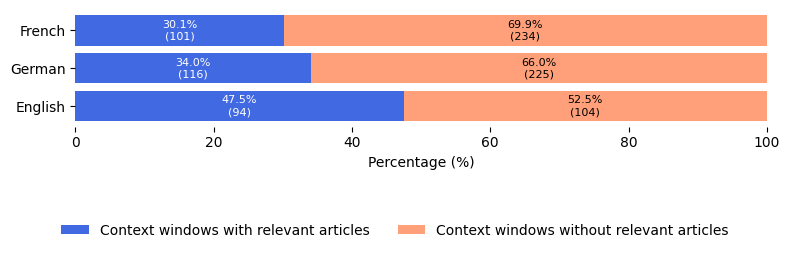

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to count relevant (with <article> tag) and irrelevant articles ("No relevant article")
def count_articles(df):
    # Count articles with <article> tag in ground_truth column
    relevant_count = df[df['ground_truth'].str.contains('<article>', na=False)].shape[0]

    # Count "No relevant article" mentions
    irrelevant_count = df[df['ground_truth'].str.contains('No relevant article', na=False)].shape[0]

    return relevant_count, irrelevant_count

# Get counts from each dataframe
english_relevant, english_irrelevant = count_articles(df_english)
french_relevant, french_irrelevant = count_articles(df_french)
german_relevant, german_irrelevant = count_articles(df_german)

# Create DataFrame for visualization
data = {
    'Language': ['English', 'French', 'German'],
    'Relevant': [english_relevant, french_relevant, german_relevant],
    'Irrelevant': [english_irrelevant, french_irrelevant, german_irrelevant]
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate totals and percentages
df['Total'] = df['Relevant'] + df['Irrelevant']
df['Relevant %'] = df['Relevant'] / df['Total'] * 100
df['Irrelevant %'] = df['Irrelevant'] / df['Total'] * 100

# Order: English, German, French
languages = ['English', 'German', 'French']
df = df.set_index('Language').loc[languages].reset_index()

# Display the counts and percentages in a table
print(df)

# Custom y-positions to remove default padding
y_pos = np.arange(len(df))
bar_height = 0.8  # Thin bars

# Plot
fig, ax = plt.subplots(figsize=(8, 2))  # Compact figure

# Stacked bars
ax.barh(y_pos, df['Relevant %'], color='royalblue', height=bar_height,
        label='Context windows with relevant articles')
ax.barh(y_pos, df['Irrelevant %'], left=df['Relevant %'], color='lightsalmon',
        height=bar_height, label='Context windows without relevant articles')

# Add labels
for i, row in df.iterrows():
    ax.text(row['Relevant %'] / 2, y_pos[i], f"{row['Relevant %']:.1f}%\n({row['Relevant']})",
            va='center', ha='center', color='white', fontsize=8)
    ax.text(row['Relevant %'] + row['Irrelevant %'] / 2, y_pos[i],
            f"{row['Irrelevant %']:.1f}%\n({row['Irrelevant']})",
            va='center', ha='center', color='black', fontsize=8)

# Axes formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(df['Language'])
ax.set_xlim(0, 100)
ax.set_xlabel('Percentage (%)')

# Remove outer spines (borders)
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Legend outside to the right
fig.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),  # Below the axes
    ncol=2,  # Put entries side by side
    frameon=False
)

# Add tight layout with rect parameter to make room for legend
plt.tight_layout(rect=[0, 0.05, 1, 1])

# Save figure (optional)
plt.savefig('dataset_composition.png', dpi=300, bbox_inches='tight')

plt.show()

## Defining column names

Grouped by language and complexity level

In [5]:
evaluation_columns_english = [
    'ChatGPT-evaluation-english-None-english-complex',
    'ChatGPT-evaluation-english-None-english-simple',
    'Claude-evaluation-english-None-english-complex',
    'Claude-evaluation-english-None-english-simple',
    'DeepSeek-evaluation-english-None-english-complex',
    'DeepSeek-evaluation-english-None-english-simple',
    'Llama3-evaluation-english-None-english-complex',
    'Llama3-evaluation-english-None-english-simple',
    'Nemotron-evaluation-english-None-english-complex',
    'Nemotron-evaluation-english-None-english-simple',
    'Qwen-evaluation-english-None-english-complex',
    'Qwen-evaluation-english-None-english-simple'
]


evaluation_columns_french = [
    'ChatGPT-evaluation-english-None-english-complex', 'ChatGPT-evaluation-english-None-english-simple',
    'ChatGPT-evaluation-english-None-french-complex', 'ChatGPT-evaluation-english-None-french-simple',
    'Claude-evaluation-english-None-english-complex', 'Claude-evaluation-english-None-english-simple',
    'Claude-evaluation-english-None-french-complex', 'Claude-evaluation-english-None-french-simple',
    'DeepSeek-evaluation-english-None-english-complex', 'DeepSeek-evaluation-english-None-english-simple',
    'DeepSeek-evaluation-english-None-french-complex', 'DeepSeek-evaluation-english-None-french-simple',
    'Llama3-evaluation-english-None-english-complex', 'Llama3-evaluation-english-None-english-simple',
    'Llama3-evaluation-english-None-french-complex', 'Llama3-evaluation-english-None-french-simple',
    'Nemotron-evaluation-english-None-english-complex', 'Nemotron-evaluation-english-None-english-simple',
    'Nemotron-evaluation-english-None-french-complex', 'Nemotron-evaluation-english-None-french-simple',
    'Qwen-evaluation-english-None-english-complex', 'Qwen-evaluation-english-None-english-simple',
    'Qwen-evaluation-english-None-french-complex', 'Qwen-evaluation-english-None-french-simple',

]
evaluation_columns_german = [
    'ChatGPT-evaluation-english-None-english-complex', 'ChatGPT-evaluation-english-None-english-simple',
    'ChatGPT-evaluation-english-None-german-complex', 'ChatGPT-evaluation-english-None-german-simple',
    'Claude-evaluation-english-None-english-complex', 'Claude-evaluation-english-None-english-simple',
    'Claude-evaluation-english-None-german-complex', 'Claude-evaluation-english-None-german-simple',
    'DeepSeek-evaluation-english-None-english-complex', 'DeepSeek-evaluation-english-None-english-simple',
    'DeepSeek-evaluation-english-None-german-complex', 'DeepSeek-evaluation-english-None-german-simple',
    'Llama3-evaluation-english-None-english-complex', 'Llama3-evaluation-english-None-english-simple',
    'Llama3-evaluation-english-None-german-complex', 'Llama3-evaluation-english-None-german-simple',
    'Nemotron-evaluation-english-None-english-complex', 'Nemotron-evaluation-english-None-english-simple',
    'Nemotron-evaluation-english-None-german-complex', 'Nemotron-evaluation-english-None-german-simple',
    'Qwen-evaluation-english-None-english-complex', 'Qwen-evaluation-english-None-english-simple',
    'Qwen-evaluation-english-None-german-complex', 'Qwen-evaluation-english-None-german-simple',

]


## Visualization: Cross-lingual model performance comparison

Which model is the best overall performer?

## Visualization: Heatmaps for average total extraction and classification score (English, French and German)

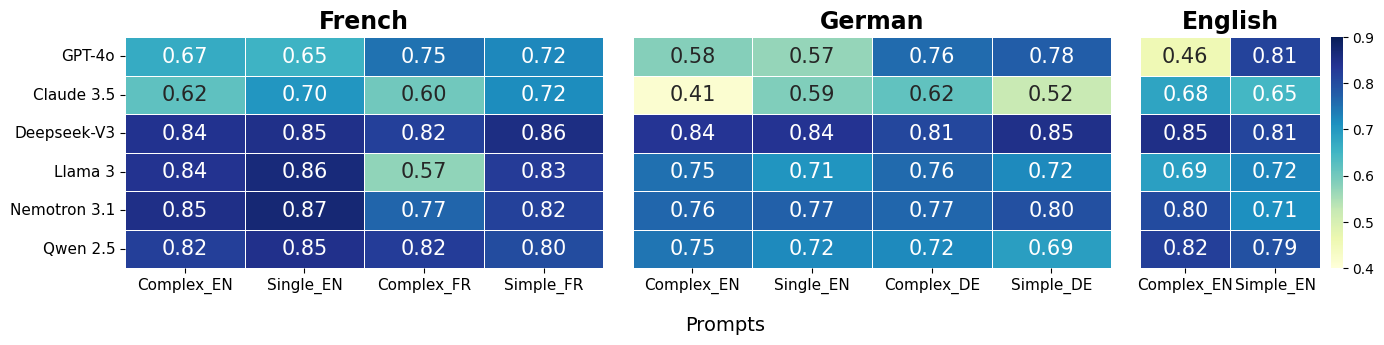

In [ ]:
import seaborn as sns

# Create figure with subplots side by side with different widths
fig = plt.figure(figsize=(16, 3))
# Create a GridSpec layout with 1 row and 10 columns
gs = fig.add_gridspec(1, 10, wspace=0.3)
# Create three subplots with different widths but more spacing - reorder so English is last
ax1 = fig.add_subplot(gs[0, 0:4])  # French takes 4 columns
ax2 = fig.add_subplot(gs[0, 4:8])  # German takes 4 columns
ax3 = fig.add_subplot(gs[0, 8:10])  # English takes 2 columns (now last)

average_score_pages_dict_english = {}
for column in evaluation_columns_english:
   result = summarize_success(df_english, column)
   average_score_pages_dict_english[column] = result['average_score_pages']

average_scores_df_english = pd.DataFrame(list(average_score_pages_dict_english.items()),
                              columns=['Column', 'Average Score Pages'])

heatmap_matrix_english = np.full((6, 2), np.nan)
for i, score in enumerate(average_scores_df_english['Average Score Pages']):
   row = i // 2
   col = i % 2
   if row < 6:  # Make sure we don't exceed matrix dimensions
       heatmap_matrix_english[row, col] = score

average_score_pages_dict_french = {}
for column in evaluation_columns_french:
   result = summarize_success(df_french, column)
   average_score_pages_dict_french[column] = result['average_score_pages']

average_scores_df_french = pd.DataFrame(list(average_score_pages_dict_french.items()),
                              columns=['Column', 'Average Score Pages'])

heatmap_matrix_french = np.full((6, 4), np.nan)
for i, score in enumerate(average_scores_df_french['Average Score Pages']):
   row = i // 4
   col = i % 4
   if row < 6:  # Make sure we don't exceed matrix dimensions
       heatmap_matrix_french[row, col] = score

average_score_pages_dict_german = {}
for column in evaluation_columns_german:
   result = summarize_success(df_german, column)
   average_score_pages_dict_german[column] = result['average_score_pages']

average_scores_df_german = pd.DataFrame(list(average_score_pages_dict_german.items()),
                              columns=['Column', 'Average Score Pages'])

heatmap_matrix_german = np.full((6, 4), np.nan)
for i, score in enumerate(average_scores_df_german['Average Score Pages']):
   row = i // 4
   col = i % 4
   if row < 6:  # Make sure we don't exceed matrix dimensions
       heatmap_matrix_german[row, col] = score

# Common settings with INCREASED FONT SIZES
row_labels = ['GPT-4o', 'Claude 3.5', 'Deepseek-V3', 'Llama 3',
             'Nemotron 3.1', 'Qwen 2.5']
cmap = 'YlGnBu'

# Set consistent vmin and vmax for all heatmaps
vmin = 0.4
vmax = 0.9

# French heatmap - first with row labels but no colorbar
sns.heatmap(heatmap_matrix_french, ax=ax1, annot=True, cmap=cmap, fmt='.2f',
           linewidths=0.7, yticklabels=row_labels, cbar=False,  # Now showing row labels
           xticklabels=['Complex_EN', 'Single_EN', 'Complex_FR', 'Simple_FR'],
           annot_kws={"size": 15}, vmin=vmin, vmax=vmax)
ax1.set_title("French", fontsize=17, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=11)  # Increased tick label size

# German heatmap - middle with no labels or colorbar
sns.heatmap(heatmap_matrix_german, ax=ax2, annot=True, cmap=cmap, fmt='.2f',
           linewidths=0.7, yticklabels=[], cbar=False,  # No y-labels for middle plot
           xticklabels=['Complex_EN', 'Single_EN', 'Complex_DE', 'Simple_DE'],
           annot_kws={"size": 15}, vmin=vmin, vmax=vmax)
ax2.set_title("German", fontsize=17, fontweight='bold')
ax2.tick_params(axis='x', which='major', labelsize=11)  # Increased tick label size

# English heatmap - last with colorbar
sns.heatmap(heatmap_matrix_english, ax=ax3, annot=True, cmap=cmap, fmt='.2f',
           linewidths=0.7, yticklabels=[], cbar=True,  # No y-labels but showing colorbar
           xticklabels=['Complex_EN', 'Simple_EN'],
           annot_kws={"size": 15}, vmin=vmin, vmax=vmax)
ax3.set_title("English", fontsize=17, fontweight='bold')
ax3.tick_params(axis='x', which='major', labelsize=11)  # Increased tick label size

# Add a centered x-label for the entire figure
fig.text(0.5, -0.1, 'Prompts', ha='center', fontsize=14)

plt.savefig('languages_temperature_0-2.png', bbox_inches='tight', dpi=300)
plt.show()

## Visualization: Percentages of Content Correctly Marked as Irrelevant and Articles Full or Partially Found

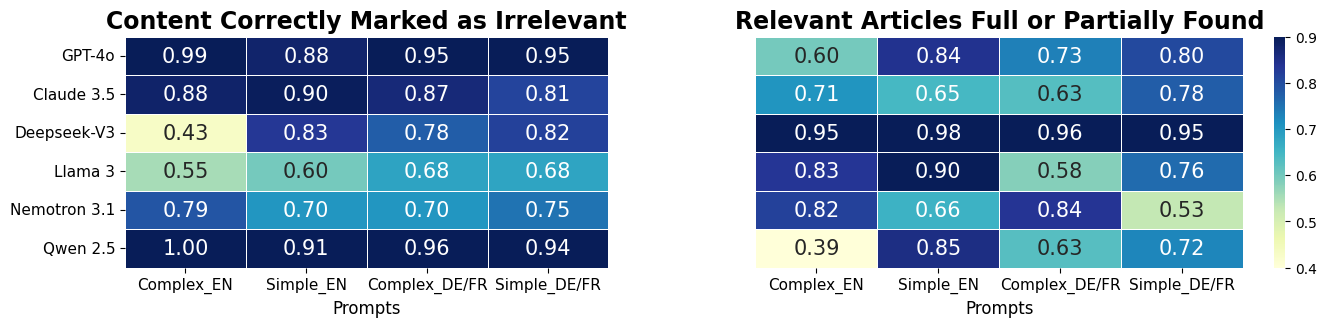

In [ ]:
# Dictionary to store results for all evaluations
all_results = {}

# Process each dataset separately with clear column mapping
def process_dataset(df, evaluation_columns, dataset_prefix):
    results = {}
    for column in evaluation_columns:
        try:
            result = summarize_success(df, column)
            # Store with dataset identifier in key
            key = f"{dataset_prefix}_{column}"
            results[key] = result
        except Exception as e:
            print(f"Error processing {column}: {e}")
            continue
    return results

# Process each dataset
german_results = process_dataset(df_german, evaluation_columns_german, 'DE')
english_results = process_dataset(df_english, evaluation_columns_english, 'EN')
french_results = process_dataset(df_french, evaluation_columns_french, 'FR')

# Combine all results
all_results.update(german_results)
all_results.update(english_results)
all_results.update(french_results)

# Define row and column labels
row_labels = ['GPT-4o', 'Claude 3.5', 'Deepseek-V3', 'Llama 3',
             'Nemotron 3.1', 'Qwen 2.5']
column_labels = ['Complex_EN', 'Simple_EN', 'Complex_DE/FR', 'Simple_DE/FR']

# Initialize matrices for both heatmaps
irrelevant_matrix = np.full((len(row_labels), len(column_labels)), np.nan)
relevant_matrix = np.full((len(row_labels), len(column_labels)), np.nan)

def get_model_index(column_name):
    model_mapping = {
        'gpt': 0,
        'claude': 1,
        'deepseek': 2,
        'llama': 3,
        'nemotron': 4,
        'qwen': 5
    }
    for model, idx in model_mapping.items():
        if model in column_name.lower():
            return idx
    return None

def get_prompt_index(column_name, dataset_prefix):
    """
    Maps column names to visualization indices based on prompt complexity and language.

    Visualization categories:
    0: Complex_EN - Complex English prompts (regardless of dataset language)
    1: Simple_EN - Simple English prompts (regardless of dataset language)
    2: Complex_DE/FR - Complex German/French prompts
    3: Simple_DE/FR - Simple German/French prompts
    """
    column_lower = column_name.lower()

    # Check for English prompts first (regardless of dataset)
    if 'english' in column_lower or 'english' in column_lower:  # Handle typo in your column names
        if 'complex' in column_lower:
            return 0  # Complex_EN
        elif 'simple' in column_lower:
            return 1  # Simple_EN

    # Then check for German/French prompts
    elif ('german' in column_lower or 'french' in column_lower) and dataset_prefix != 'EN':
        if 'complex' in column_lower:
            return 2  # Complex_DE/FR
        elif 'simple' in column_lower:
            return 3  # Simple_DE/FR

    # If can't determine, use some fallback logic
    elif dataset_prefix != 'EN':  # For non-English datasets
        if 'english' not in column_lower and 'complex' in column_lower:
            return 2  # Complex_DE/FR (fallback)
        elif 'english' not in column_lower and 'simple' in column_lower:
            return 3  # Simple_DE/FR (fallback)

    return None  # Can't determine mapping

# Fill matrices
for full_column, result in all_results.items():
    dataset_prefix, column = full_column.split('_', 1)
    model_idx = get_model_index(column)
    prompt_idx = get_prompt_index(column, dataset_prefix)

    if model_idx is not None and prompt_idx is not None:
        irrelevant_matrix[model_idx, prompt_idx] = result['non_relevant_percentages']['true_negative']
        relevant_matrix[model_idx, prompt_idx] = result['relevant_percentages']['total_relevant_percentage']

# Create figure with subplots side by side with different widths
fig = plt.figure(figsize=(16, 3))
# Create a GridSpec layout with 1 row and 10 columns
gs = fig.add_gridspec(1, 10, wspace=0.2)
# Create two subplots with specific grid positions
ax1 = fig.add_subplot(gs[0, 0:4])  # Irrelevant performance takes 5 columns
ax2 = fig.add_subplot(gs[0, 5:10])  # Relevant performance takes 5 columns

# Set consistent vmin and vmax for all heatmaps
vmin = 0.4
vmax = 0.9
cmap = 'YlGnBu'

# Plot first heatmap - with row labels but no colorbar
sns.heatmap(irrelevant_matrix,
            ax=ax1,
            annot=True,
            cmap=cmap,
            fmt='.2f',
            linewidths=0.7,
            yticklabels=row_labels,
            cbar=False,
            xticklabels=column_labels,
            annot_kws={"size": 15},
            vmin=vmin,
            vmax=vmax)

ax1.set_title("Content Correctly Marked as Irrelevant", fontsize=17, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=11)  # Increased tick label size
ax1.set_xlabel("Prompts", fontsize=12)
# Plot second heatmap - with colorbar but no row labels
sns.heatmap(relevant_matrix,
            ax=ax2,
            annot=True,
            cmap=cmap,
            fmt='.2f',
            linewidths=0.7,
            yticklabels=[],
            cbar=True,
            xticklabels=column_labels,
            annot_kws={"size": 15},
            vmin=vmin,
            vmax=vmax)

ax2.set_title("Relevant Articles Full or Partially Found", fontsize=17, fontweight='bold')
ax2.tick_params(axis='x', which='major', labelsize=11)  # Increased tick label size
ax2.set_xlabel("Prompts", fontsize=12)

# Add a centered x-label for the entire figure

plt.savefig('relevant_irrelevant_temperature_0-2.png', bbox_inches='tight', dpi=300)
plt.show()